In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Фиксируем seed для воспроизводимости
np.random.seed(42)
random.seed(42)

branches = ['A', 'B', 'C']
product_lines = ['Health and beauty', 'Electronic accessories',
                 'Home and lifestyle', 'Sports and travel', 'Food and beverages']

start_date = datetime(2023, 1, 1)
n_rows = 1500

data = {
    'Invoice ID': [f"INV-{np.random.randint(10000, 99999)}" for _ in range(n_rows)],
    'User_ID': np.random.randint(100, 500, n_rows),
    'Date': [(start_date + timedelta(days=random.randint(0, 90))).strftime('%Y-%m-%d') for _ in range(n_rows)],
    'Branch': np.random.choice(branches, n_rows),
    'Product line': np.random.choice(product_lines, n_rows),
    'Unit price': np.random.uniform(10.0, 100.0, n_rows).round(2),
    'Quantity': np.random.randint(1, 10, n_rows),
    'Rating': np.random.uniform(2.0, 10.0, n_rows).round(1)
}

df_mock = pd.DataFrame(data)
df_mock['Total'] = df_mock['Unit price'] * df_mock['Quantity']

# Вносим "грязные" данные
df_mock.loc[np.random.choice(df_mock.index, 50, replace=False), 'Rating'] = np.nan
df_mock['Total'] = df_mock['Total'].apply(lambda x: f"{x:,.2f}")

# Сохраняем файл в текущую директорию
df_mock.to_csv('supermarket_sales_mock.csv', index=False)
print("Успех: Датасет 'supermarket_sales_mock.csv' сгенерирован и сохранен!")

Успех: Датасет 'supermarket_sales_mock.csv' сгенерирован и сохранен!


1. Импорт библиотек и загрузка данных

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('supermarket_sales_mock.csv')
display(df.head())
display(df.info())

,Invoice ID,User_ID,Date,Branch,Product line,Unit price,Quantity,Rating,Total
0,INV-25795,171,2023-03-23,C,Food and beverages,25.49,2,NaN,50.98
1,INV-10860,247,2023-01-15,A,Electronic accessories,89.09,5,6.6,445.45
2,INV-86820,448,2023-01-04,C,Home and lifestyle,60.25,6,2.4,361.50
3,INV-64886,162,2023-02-05,B,Home and lifestyle,88.29,5,7.0,441.45
4,INV-16265,409,2023-02-01,C,Electronic accessories,43.44,9,7.0,390.96


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Invoice ID    1500 non-null   object 
 1   User_ID       1500 non-null   int64  
 2   Date          1500 non-null   object 
 3   Branch        1500 non-null   object 
 4   Product line  1500 non-null   object 
 5   Unit price    1500 non-null   float64
 6   Quantity      1500 non-null   int64  
 7   Rating        1450 non-null   float64
 8   Total         1500 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 105.6+ KB


None

2. Очистка и предобработка данных

In [4]:
# Исправление типов данных
df['Date'] = pd.to_datetime(df['Date'])

if df['Total'].dtype == 'O':
    df['Total'] = df['Total'].str.replace(',', '').astype(float)

# Обработка пропусков
df['Rating'] = df.groupby('Product line')['Rating'].transform(lambda x: x.fillna(x.median()))

print("Количество пропусков после очистки:\n", df.isnull().sum())
print("\nТипы данных после очистки:\n", df.dtypes)

Количество пропусков после очистки:
 Invoice ID      0
User_ID         0
Date            0
Branch          0
Product line    0
Unit price      0
Quantity        0
Rating          0
Total           0
dtype: int64

Типы данных после очистки:
 Invoice ID              object
User_ID                  int64
Date            datetime64[ns]
Branch                  object
Product line            object
Unit price             float64
Quantity                 int64
Rating                 float64
Total                  float64
dtype: object


3. Расчет базовых продуктовых метрик (AOV, ARPU)

In [5]:
# Расчет среднего чека (Average Order Value)
aov = df['Total'].mean()
print(f"Средний чек (AOV): ${aov:.2f}")

# Расчет средней выручки на пользователя (Average Revenue Per User)
arpu = df.groupby('User_ID')['Total'].sum().mean()
print(f"Средняя выручка на пользователя (ARPU): ${arpu:.2f}")

# Общая выручка за период
total_revenue = df['Total'].sum()
print(f"Общая выручка: ${total_revenue:,.2f}")

Средний чек (AOV): $268.33
Средняя выручка на пользователя (ARPU): $1034.69
Общая выручка: $402,492.55


4. Исследовательский анализ данных (EDA) и поиск трендов

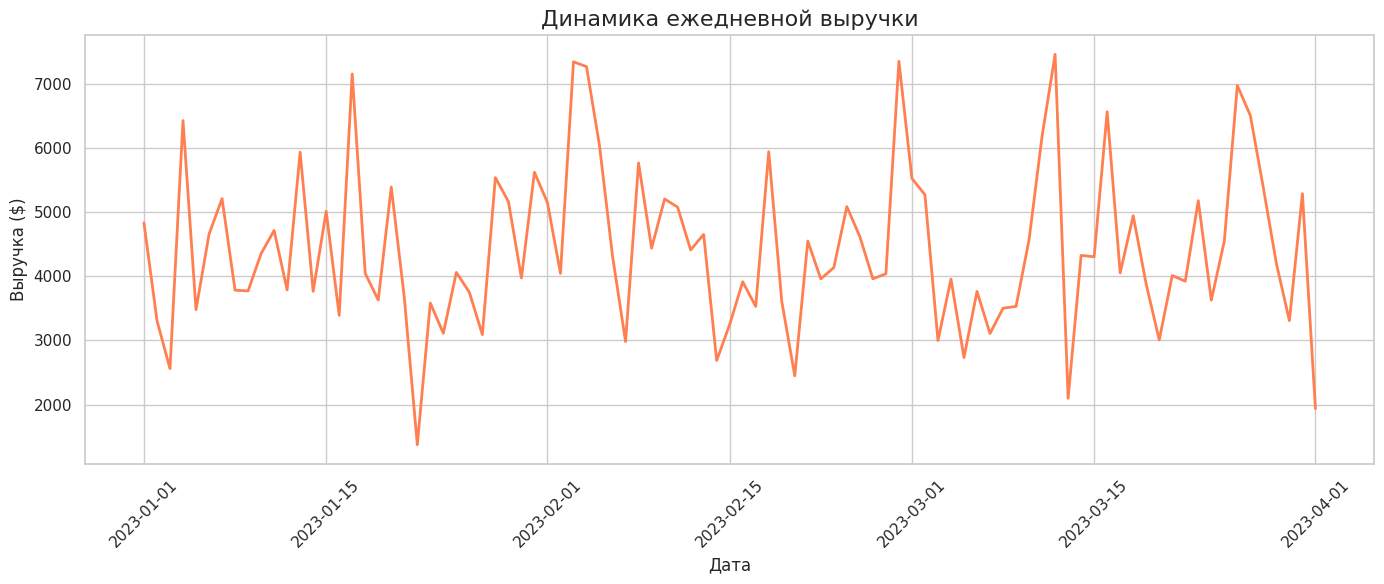

In [6]:
plt.figure(figsize=(14, 6))

# Агрегируем ежедневную выручку
daily_revenue = df.groupby('Date')['Total'].sum().reset_index()

# График 1: Динамика ежедневной выручки
sns.lineplot(data=daily_revenue, x='Date', y='Total', color='coral', linewidth=2)
plt.title('Динамика ежедневной выручки', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Выручка ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1297/1511321786.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_product, x='Total', y='Product line', ax=axes[0], palette='viridis')
/tmp/ipykernel_1297/1511321786.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_branch, x='Branch', y='Total', ax=axes[1], palette='pastel')


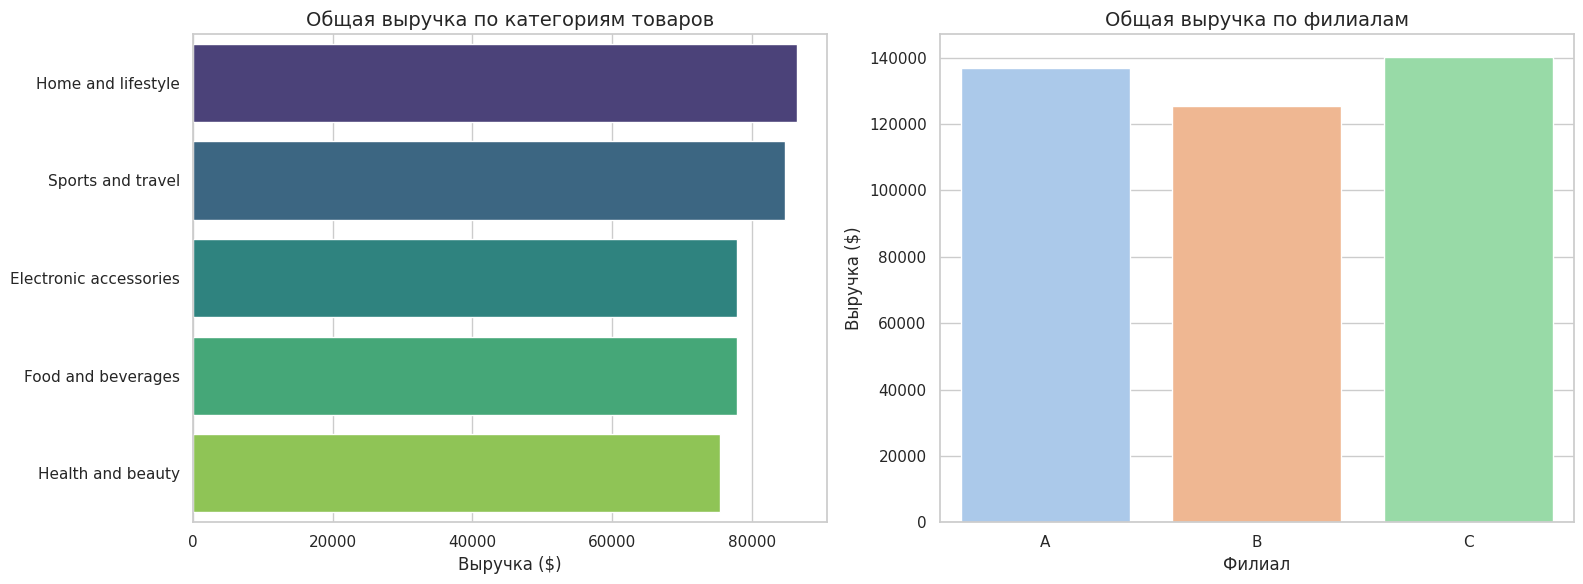

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 2: Выручка по категориям товаров
revenue_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=revenue_by_product, x='Total', y='Product line', ax=axes[0], palette='viridis')
axes[0].set_title('Общая выручка по категориям товаров', fontsize=14)
axes[0].set_xlabel('Выручка ($)')
axes[0].set_ylabel('')

# График 3: Выручка по филиалам
revenue_by_branch = df.groupby('Branch')['Total'].sum().reset_index()
sns.barplot(data=revenue_by_branch, x='Branch', y='Total', ax=axes[1], palette='pastel')
axes[1].set_title('Общая выручка по филиалам', fontsize=14)
axes[1].set_xlabel('Филиал')
axes[1].set_ylabel('Выручка ($)')

plt.tight_layout()
plt.show()